In [2]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


Saving Sample - Superstore.csv to Sample - Superstore (2).csv
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Pr

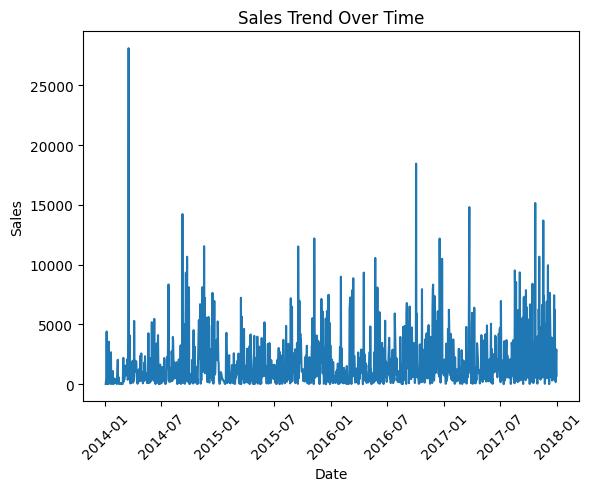

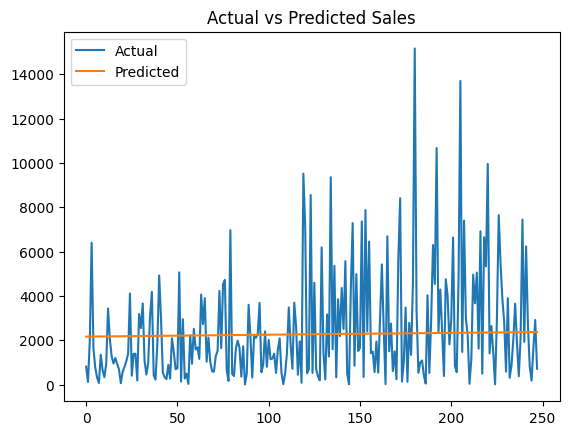


Future Forecast:
        Date  Predicted Sales
0 2017-12-30      2369.079680
1 2017-12-31      2369.848118
2 2018-01-01      2370.616556
3 2018-01-02      2371.384993
4 2018-01-03      2372.153431
5 2018-01-04      2372.921869
6 2018-01-05      2373.690306
7 2018-01-06      2374.458744
8 2018-01-07      2375.227182
9 2018-01-08      2375.995619

Business Insight:
This forecast helps businesses predict demand, manage inventory, and reduce losses.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


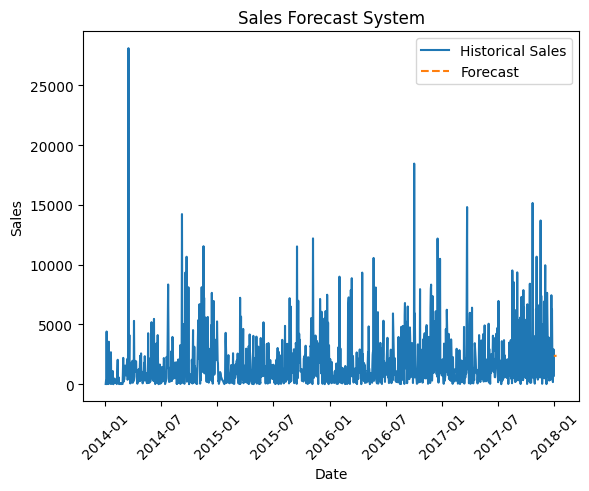

In [5]:
# STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# STEP 2: Upload Dataset (Colab)
from google.colab import files
uploaded = files.upload()

# STEP 3: Load Dataset (AUTO detect file name)
import os
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, encoding='latin1')

print(df.head())

# STEP 4: Convert Date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# STEP 5: Sort Data
df = df.sort_values('Order Date')

# STEP 6: Daily Sales
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# STEP 7: Plot Trend
plt.figure()
plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# STEP 8: Convert Date to Number
daily_sales['Date_Ordinal'] = daily_sales['Order Date'].map(pd.Timestamp.toordinal)

X = daily_sales[['Date_Ordinal']]
y = daily_sales['Sales']

# STEP 9: Train Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

# STEP 10: Predict
y_pred = model.predict(X_test)

# STEP 11: Plot Prediction
plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

# STEP 12: Future Forecast
future_dates = pd.date_range(start=daily_sales['Order Date'].max(), periods=10)
future_ordinal = future_dates.map(pd.Timestamp.toordinal)

future_pred = model.predict(future_ordinal.values.reshape(-1,1))

future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Sales': future_pred
})

print("\nFuture Forecast:")
print(future_df)

# STEP 13: FINAL OUTPUT + INSIGHT
print("\nBusiness Insight:")
print("This forecast helps businesses predict demand, manage inventory, and reduce losses.")

# FINAL PLOT (Historical + Forecast)
plt.figure()
plt.plot(daily_sales['Order Date'], daily_sales['Sales'], label="Historical Sales")
plt.plot(future_df['Date'], future_df['Predicted Sales'], label="Forecast", linestyle='dashed')
plt.title("Sales Forecast System")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()